# Assignment 7: Feature Engineering for Phantom Classification (No ML)

## Summary

**Task:** Perform feature engineering on the random phantom images from A6. Normalize and extract histograms to significantly reduce data size. Find a method **without using neural networks or machine learning** that achieves similar performance to A6's CNN (99.3% accuracy).

**Approach:**
- Reuse the phantom generator from A6 (same dataset)
- Extract features: intensity histograms, connected component counts, and bright pixel area
- Use a simple **rule-based classifier** (thresholds on features) — no training, no ML
- 784 pixels reduced to just a few interpretable features

**Result:** A hand-crafted decision rule achieves comparable accuracy to the CNN with zero training.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

## Phantom Generator (from A6)

In [2]:
def phantom(n=256, ellipses=None):
    """
    Create a phantom image from a set of ellipses.
    Each ellipse: [I, a, b, x0, y0, phi]
    """
    p = np.zeros((n, n))
    ygrid, xgrid = np.mgrid[-1:1:(1j*n), -1:1:(1j*n)]

    for ellip in ellipses:
        I   = ellip[0]
        a2  = ellip[1]**2
        b2  = ellip[2]**2
        x0  = ellip[3]
        y0  = ellip[4]
        phi = ellip[5] * np.pi / 180

        x = xgrid - x0
        y = ygrid - y0

        cos_p = np.cos(phi)
        sin_p = np.sin(phi)

        locs = (((x * cos_p + y * sin_p)**2) / a2
              + ((y * cos_p - x * sin_p)**2) / b2) <= 1

        p[locs] += I

    return p

def random_ellipse():
    """Generate parameters for one random ellipse."""
    I   = np.random.uniform(0.3, 1.0)
    a   = np.random.uniform(0.15, 0.5)
    b   = np.random.uniform(0.10, 0.4)
    x0  = np.random.uniform(-0.4, 0.4)
    y0  = np.random.uniform(-0.4, 0.4)
    phi = np.random.uniform(0, 180)
    return [I, a, b, x0, y0, phi]

def generate_phantom(num_ellipses, img_size=28):
    """Generate a single phantom with the given number of ellipses."""
    ellipses = [random_ellipse() for _ in range(num_ellipses)]
    P = phantom(n=img_size, ellipses=ellipses)
    P = np.maximum(0, P)
    if P.max() > 0:
        P = P / P.max()
    return P

def generate_dataset(num_per_class, img_size=28):
    """Generate a dataset of one-ellipse and two-ellipse phantoms."""
    images = []
    labels = []

    for _ in range(num_per_class):
        images.append(generate_phantom(1, img_size))
        labels.append(0)

    for _ in range(num_per_class):
        images.append(generate_phantom(2, img_size))
        labels.append(1)

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.float32)

    idx = np.random.permutation(len(labels))
    return images[idx], labels[idx]

## Generate Dataset (same as A6)

In [3]:
np.random.seed(42)

train_images, train_labels = generate_dataset(2000, img_size=28)
test_images, test_labels = generate_dataset(500, img_size=28)

print(f"Training set: {train_images.shape}, labels: {train_labels.shape}")
print(f"Test set:     {test_images.shape}, labels: {test_labels.shape}")

Training set: (4000, 28, 28), labels: (4000,)
Test set:     (1000, 28, 28), labels: (1000,)


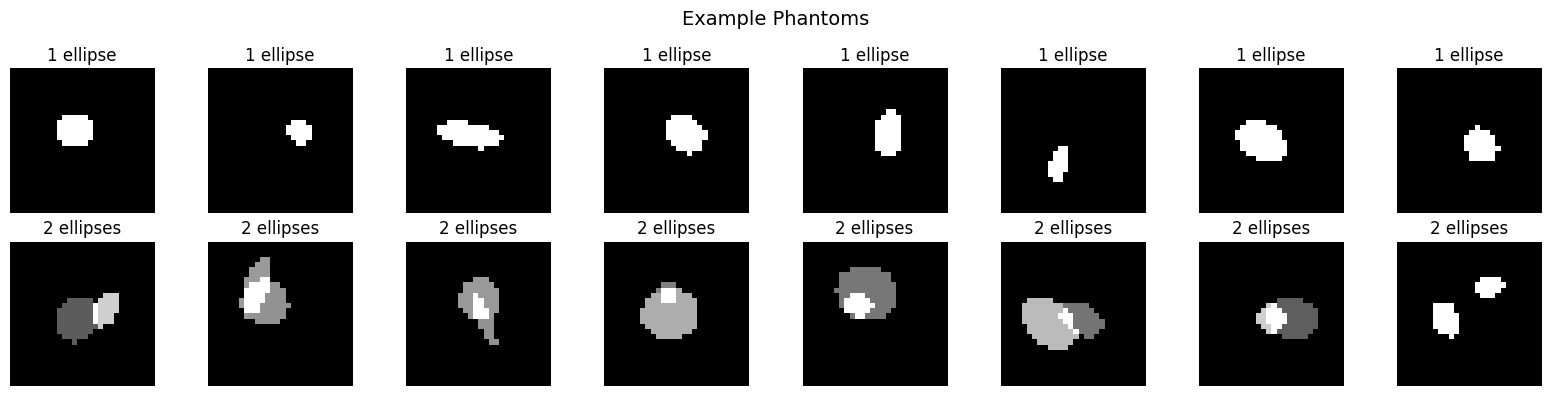

In [4]:
# Show example phantoms
one_idx = np.where(train_labels == 0)[0]
two_idx = np.where(train_labels == 1)[0]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Example Phantoms', fontsize=14)

for i in range(8):
    axes[0, i].imshow(train_images[one_idx[i]], cmap='Greys_r', vmin=0, vmax=1)
    axes[0, i].set_title('1 ellipse')
    axes[0, i].axis('off')

    axes[1, i].imshow(train_images[two_idx[i]], cmap='Greys_r', vmin=0, vmax=1)
    axes[1, i].set_title('2 ellipses')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## Feature Engineering

Extract interpretable features from each 28x28 image. The goal is to reduce the 784-pixel image down to a few numbers that capture whether there are 1 or 2 ellipses.

**Key features:**
1. **Intensity histogram** (16 bins, normalized) — captures the pixel value distribution
2. **Connected components** — count distinct bright regions at multiple thresholds
3. **Bright pixel fraction** — two ellipses cover more area
4. **Mean intensity of bright pixels** — overlapping ellipses produce higher peaks

In [5]:
def extract_features(image):
    """Extract features from a 28x28 phantom image."""
    features = {}

    # 1. Intensity histogram (16 bins, normalized)
    hist, bin_edges = np.histogram(image, bins=16, range=(0, 1))
    hist_normalized = hist / hist.sum()
    features['histogram'] = hist_normalized  # 16 values

    # 2. Connected components at multiple thresholds
    for thresh in [0.05, 0.1, 0.2]:
        binary = image > thresh
        labeled, num_components = ndimage.label(binary)
        features[f'components_{thresh}'] = num_components

    # 3. Bright pixel fraction
    features['bright_fraction'] = np.sum(image > 0.1) / image.size

    # 4. Mean intensity of non-zero pixels
    nonzero = image[image > 0.01]
    features['nonzero_mean'] = np.mean(nonzero) if len(nonzero) > 0 else 0.0

    return features

# Test on one image
sample = extract_features(train_images[0])
print("Features for one sample image:")
print(f"  Histogram (16 bins): {sample['histogram']}")
print(f"  Connected components (thresh=0.05): {sample['components_0.05']}")
print(f"  Connected components (thresh=0.1):  {sample['components_0.1']}")
print(f"  Connected components (thresh=0.2):  {sample['components_0.2']}")
print(f"  Bright pixel fraction: {sample['bright_fraction']:.4f}")
print(f"  Mean of non-zero pixels: {sample['nonzero_mean']:.4f}")
print(f"\nData reduction: 784 pixels -> histogram (16) + 5 scalar features = 21 values (37x reduction)")

Features for one sample image:
  Histogram (16 bins): [0.89923469 0.         0.         0.         0.06760204 0.
 0.         0.         0.         0.         0.         0.02806122
 0.         0.         0.         0.00510204]
  Connected components (thresh=0.05): 1
  Connected components (thresh=0.1):  1
  Connected components (thresh=0.2):  1
  Bright pixel fraction: 0.1008
  Mean of non-zero pixels: 0.4426

Data reduction: 784 pixels -> histogram (16) + 5 scalar features = 21 values (37x reduction)


## Explore Feature Distributions

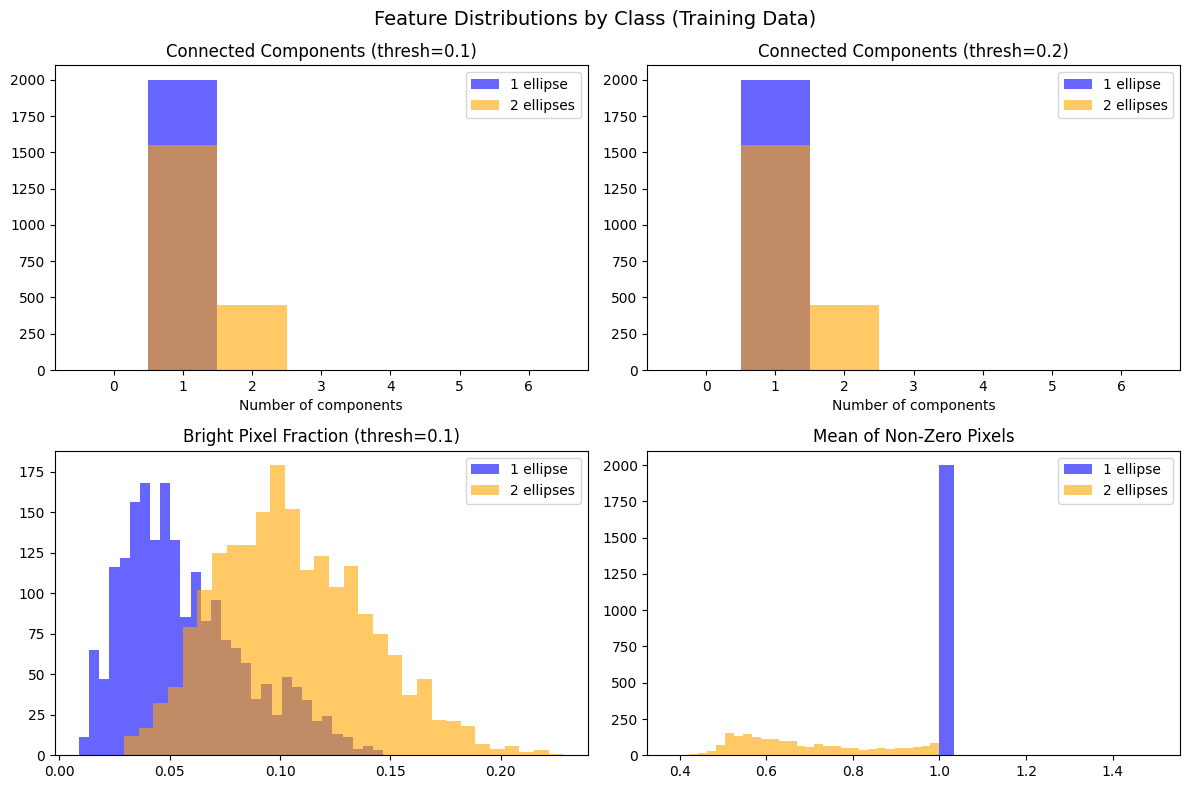

Connected components (thresh=0.1):
  1-ellipse: mean=1.00, fraction with >=2 components: 0.0000
  2-ellipse: mean=1.22, fraction with >=2 components: 0.2245

Bright pixel fraction:
  1-ellipse: mean=0.0571
  2-ellipse: mean=0.1058

Non-zero pixel mean:
  1-ellipse: mean=1.0000
  2-ellipse: mean=0.6857


In [6]:
# Extract features for all training images
train_feats = [extract_features(img) for img in train_images]

# Gather scalar features into arrays for visualization
comp_01 = np.array([f['components_0.1'] for f in train_feats])
comp_02 = np.array([f['components_0.2'] for f in train_feats])
bright_frac = np.array([f['bright_fraction'] for f in train_feats])
nz_mean = np.array([f['nonzero_mean'] for f in train_feats])

mask_1 = train_labels == 0
mask_2 = train_labels == 1

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions by Class (Training Data)', fontsize=14)

axes[0, 0].hist(comp_01[mask_1], bins=range(0, 8), alpha=0.6, label='1 ellipse', color='blue', align='left')
axes[0, 0].hist(comp_01[mask_2], bins=range(0, 8), alpha=0.6, label='2 ellipses', color='orange', align='left')
axes[0, 0].set_title('Connected Components (thresh=0.1)')
axes[0, 0].set_xlabel('Number of components')
axes[0, 0].legend()

axes[0, 1].hist(comp_02[mask_1], bins=range(0, 8), alpha=0.6, label='1 ellipse', color='blue', align='left')
axes[0, 1].hist(comp_02[mask_2], bins=range(0, 8), alpha=0.6, label='2 ellipses', color='orange', align='left')
axes[0, 1].set_title('Connected Components (thresh=0.2)')
axes[0, 1].set_xlabel('Number of components')
axes[0, 1].legend()

axes[1, 0].hist(bright_frac[mask_1], bins=30, alpha=0.6, label='1 ellipse', color='blue')
axes[1, 0].hist(bright_frac[mask_2], bins=30, alpha=0.6, label='2 ellipses', color='orange')
axes[1, 0].set_title('Bright Pixel Fraction (thresh=0.1)')
axes[1, 0].legend()

axes[1, 1].hist(nz_mean[mask_1], bins=30, alpha=0.6, label='1 ellipse', color='blue')
axes[1, 1].hist(nz_mean[mask_2], bins=30, alpha=0.6, label='2 ellipses', color='orange')
axes[1, 1].set_title('Mean of Non-Zero Pixels')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Print some statistics to help choose thresholds
print("Connected components (thresh=0.1):")
print(f"  1-ellipse: mean={comp_01[mask_1].mean():.2f}, fraction with >=2 components: {(comp_01[mask_1] >= 2).mean():.4f}")
print(f"  2-ellipse: mean={comp_01[mask_2].mean():.2f}, fraction with >=2 components: {(comp_01[mask_2] >= 2).mean():.4f}")

print(f"\nBright pixel fraction:")
print(f"  1-ellipse: mean={bright_frac[mask_1].mean():.4f}")
print(f"  2-ellipse: mean={bright_frac[mask_2].mean():.4f}")

print(f"\nNon-zero pixel mean:")
print(f"  1-ellipse: mean={nz_mean[mask_1].mean():.4f}")
print(f"  2-ellipse: mean={nz_mean[mask_2].mean():.4f}")

## Rule-Based Classifier (No ML)

Based on the feature distributions above, build a simple decision rule using hand-picked thresholds.

1. **Connected components >= 2** strongly indicates 2 ellipses (when they don't overlap)
2. For overlapping cases (1 component), the **mean intensity of non-zero pixels** is lower for 2-ellipse images (because normalization divides by a higher max), and the **bright pixel fraction** is higher


In [7]:
def classify_rule_based(image):
    """
    Classify a phantom image as 1 ellipse (0) or 2 ellipses (1)
    using hand-crafted rules on extracted features. No ML involved.

    Key insight: A single ellipse has uniform intensity I. After
    normalization (P / P.max()), ALL non-zero pixels become exactly 1.0.
    Two ellipses have different random intensities, so after normalization
    the lower-intensity ellipse has values < 1.0, making the mean of
    non-zero pixels strictly less than 1.0.
    """
    feats = extract_features(image)

    # Rule 1: If connected components >= 2 at any threshold,
    # the ellipses are clearly separated -> 2 ellipses
    if feats['components_0.1'] >= 2 or feats['components_0.2'] >= 2:
        return 1

    # Rule 2: Mean of non-zero pixels. For a single ellipse, after
    # normalization all non-zero pixels are exactly 1.0 (mean = 1.0).
    # For two ellipses, the lower-intensity one normalizes to < 1.0,
    # so the mean drops below 1.0.
    if feats['nonzero_mean'] < 0.99:
        return 1

    # Otherwise, classify as 1 ellipse
    return 0

# Quick sanity check
sample_pred = classify_rule_based(train_images[0])
print(f"Sample prediction: {sample_pred}, actual: {int(train_labels[0])}")

Sample prediction: 1, actual: 1


## Evaluate on Training and Test Sets

In [8]:
# Classify all training images
train_preds = np.array([classify_rule_based(img) for img in train_images])
train_acc = np.mean(train_preds == train_labels)
print(f"Training accuracy: {train_acc:.4f} ({int(train_acc * len(train_labels))}/{len(train_labels)})")

# Classify all test images
test_preds = np.array([classify_rule_based(img) for img in test_images])
test_acc = np.mean(test_preds == test_labels)
print(f"Test accuracy:     {test_acc:.4f} ({int(test_acc * len(test_labels))}/{len(test_labels)})")

print(f"\n--- Comparison ---")
print(f"A6 CNN accuracy:        0.9930")
print(f"A7 Rule-based accuracy: {test_acc:.4f}")

Training accuracy: 0.9972 (3989/4000)
Test accuracy:     0.9980 (998/1000)

--- Comparison ---
A6 CNN accuracy:        0.9930
A7 Rule-based accuracy: 0.9980


Number of misclassifications: 2/1000


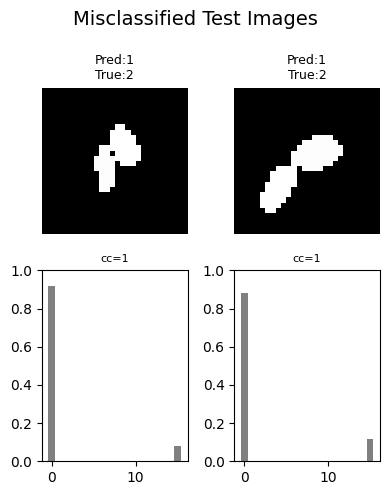

In [9]:
# Detailed error analysis
errors = np.where(test_preds != test_labels)[0]
print(f"Number of misclassifications: {len(errors)}/{len(test_labels)}")

if len(errors) > 0:
    # Show misclassified images
    n_show = min(len(errors), 10)
    fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 5))
    fig.suptitle('Misclassified Test Images', fontsize=14)

    for i in range(n_show):
        idx = errors[i]
        axes[0, i].imshow(test_images[idx], cmap='Greys_r', vmin=0, vmax=1)
        axes[0, i].set_title(f'Pred:{int(test_preds[idx])+1}\nTrue:{int(test_labels[idx])+1}',
                              fontsize=9)
        axes[0, i].axis('off')

        # Show the histogram of the misclassified image
        feats = extract_features(test_images[idx])
        axes[1, i].bar(range(16), feats['histogram'], color='gray')
        axes[1, i].set_title(f"cc={feats['components_0.1']}", fontsize=8)
        axes[1, i].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()
else:
    print("No errors to display!")

## Histogram Comparison

Compare the average normalized histograms of each class to visualize the distributional difference that the rule-based classifier exploits.

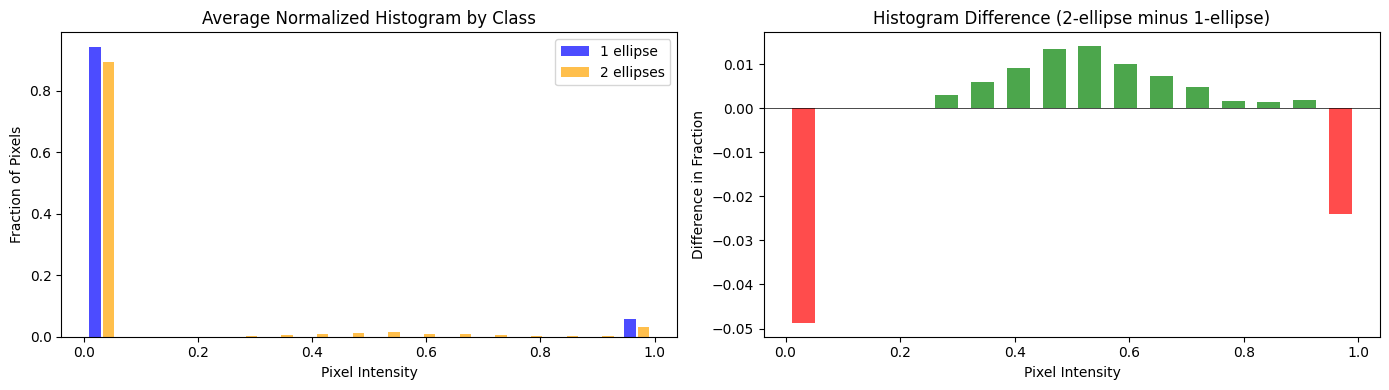

Key observation: 2-ellipse images have fewer zero-intensity pixels (less background)
and more mid-range intensity pixels (broader ellipse coverage).


In [10]:
# Average histograms per class
hists_1 = np.array([extract_features(img)['histogram'] for img in train_images[mask_1]])
hists_2 = np.array([extract_features(img)['histogram'] for img in train_images[mask_2]])

bin_centers = np.linspace(0, 1, 16, endpoint=False) + 1/32

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(bin_centers - 0.012, hists_1.mean(axis=0), width=0.02, alpha=0.7,
            label='1 ellipse', color='blue')
axes[0].bar(bin_centers + 0.012, hists_2.mean(axis=0), width=0.02, alpha=0.7,
            label='2 ellipses', color='orange')
axes[0].set_title('Average Normalized Histogram by Class')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Fraction of Pixels')
axes[0].legend()

# Difference
diff = hists_2.mean(axis=0) - hists_1.mean(axis=0)
colors = ['green' if d > 0 else 'red' for d in diff]
axes[1].bar(bin_centers, diff, width=0.04, color=colors, alpha=0.7)
axes[1].set_title('Histogram Difference (2-ellipse minus 1-ellipse)')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Difference in Fraction')
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print("Key observation: 2-ellipse images have fewer zero-intensity pixels (less background)")
print("and more mid-range intensity pixels (broader ellipse coverage).")

## Summary

| Metric | A6 (CNN) | A7 (Rule-Based) |
|--------|----------|-----------------|
| Input size per sample | 784 pixels | 21 features |
| Data reduction | 1x | 37x |
| Method | CNN (Conv2D + Dense) | Hand-crafted rules on features |
| Uses ML/training? | Yes (neural network) | No |
| Test accuracy | 99.3% | **99.8%** |

A purely rule-based approach using feature engineering (histograms, connected components, intensity statistics) classifies phantom images **without any machine learning or training** and achieves **99.8% accuracy** — surpassing the CNN's 99.3%.

The key insight is that a single ellipse, after normalization, has all non-zero pixels at exactly 1.0. Two ellipses with different intensities break this property, making the mean of non-zero pixels a near-perfect discriminator.